# Code: Time Series Toolbox

*Prepared by Michael Lawrence Castanares, PhD*

`To begin is for everyone. To persevere is for saints - St. Josemaria Escriva`



Note: Most of the contents are taken from my MSDS Time Series class taught by Prof. Sebastian Ibanez, PhD

In [1]:
%%capture
!pip install statsforecast

In [2]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
)

In [3]:
# Helper functions
def apply_chart_template(filename=None):
    """
    Decorator to apply minimal plot styling by removing spines and the y-axis.
    """
    def decorator(func):
        def wrapper(*args, **kwargs):
            result = func(*args, **kwargs)
            for spine in ['top', 'right']:
                plt.gca().spines[spine].set_visible(False)
            #set font size
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            #remove x-labels
            plt.xlabel('')  # Remove x-axis title
            #plt.gca().axes.get_yaxis().set_visible(False)
            plt.tight_layout()
            if filename:
                plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.show()
            return result
        return wrapper
    return decorator

### AUD/PHP Exchange Rate
The AUD/PH Exchange rate daily series was sourced from the [Reserve Bank of Australia](https://www.rba.gov.au/statistics/historical-data.html#exchange-rates). We select FXRPHP column only but the analysis can also be extended to other currencies in the dataset.

In [7]:
SELECT_COL = ['Series ID','FXRPHP']
loc_TRAIN = pd.to_datetime('2026-02-01')

df_aud = pd.read_excel('2023-current.xls',
                       sheet_name='Data',
                       skiprows=10)
df_aud = df_aud[SELECT_COL]
df_aud = df_aud.rename(columns={
    'Series ID':'date',
    'FXRPHP':'y'})

# Upon inspection, the date column does not have regular intervals
# Thus we need to create a regular data range and fillin values

print('*'*75)
print(f'Note: The series have irregular intervals. We will create a regular date range and fill in missing values using forward fill method.')
display(df_aud.tail(10))


***************************************************************************
Note: The series have irregular intervals. We will create a regular date range and fill in missing values using forward fill method.


,date,y
777,2026-02-06,40.66
778,2026-02-09,41.06
779,2026-02-10,41.35
780,2026-02-11,41.48
781,2026-02-12,41.37
782,2026-02-13,41.09
783,2026-02-16,41.08
784,2026-02-17,40.99
785,2026-02-18,40.91
786,2026-02-19,40.90


We setup the series into a standard format accepted by Nixtla packages. The table should be in long-format with columns: 

* date (`ds`),
* variable name (`unique_id`), and 
* value (`y`).

We will also fillin missing values using the recent past values (forward-fill method)

In [8]:
#fillin missing values from recent past value (ffill)
df = pd.DataFrame({'ds': pd.date_range(start=df_aud['date'].min(),
                                           end=df_aud['date'].max(),
                                           freq='D')})
df['unique_id'] = 'AUDPHP'
df['y'] = df_aud.set_index('date').reindex(df['ds'])['y'].values
df.fillna(method='ffill', inplace=True)

df

/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_11909/2498781778.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,ds,unique_id,y
0,2023-01-03,AUDPHP,38.07
1,2023-01-04,AUDPHP,38.12
2,2023-01-05,AUDPHP,38.12
3,2023-01-06,AUDPHP,37.66
4,2023-01-07,AUDPHP,37.66
...,...,...,...
1139,2026-02-15,AUDPHP,41.09
1140,2026-02-16,AUDPHP,41.08
1141,2026-02-17,AUDPHP,40.99
1142,2026-02-18,AUDPHP,40.91


We then split the data. A standard Modeling framework would divide the dataset into three parts:

* Train set (70%) - Data is used to fit the model.
* Validation set (10%) - Data used to optimize the parameters of the model and validate if they are robust.
* Test set (20%) - Data "not seen" by the model and is used to check model performance.

**insight** This data split is common for cross-section data (or data that does not follow a sequence). But how about for time-series where the order of the values is important? There are specfic approaches for time-series such as moving/sliding or expanding window for cross-validation (could be a separate blog discussion).

But at this point, it is important to note that the choice of the data split (here at 02/02/2026) could affect the modelling and its results.

Test set size: 19


,ds,unique_id,y
1125,2026-02-01,AUDPHP,41.26
1126,2026-02-02,AUDPHP,40.90
1127,2026-02-03,AUDPHP,41.27
1128,2026-02-04,AUDPHP,41.41
1129,2026-02-05,AUDPHP,41.02
1130,2026-02-06,AUDPHP,40.66
1131,2026-02-07,AUDPHP,40.66
1132,2026-02-08,AUDPHP,40.66
1133,2026-02-09,AUDPHP,41.06
1134,2026-02-10,AUDPHP,41.35


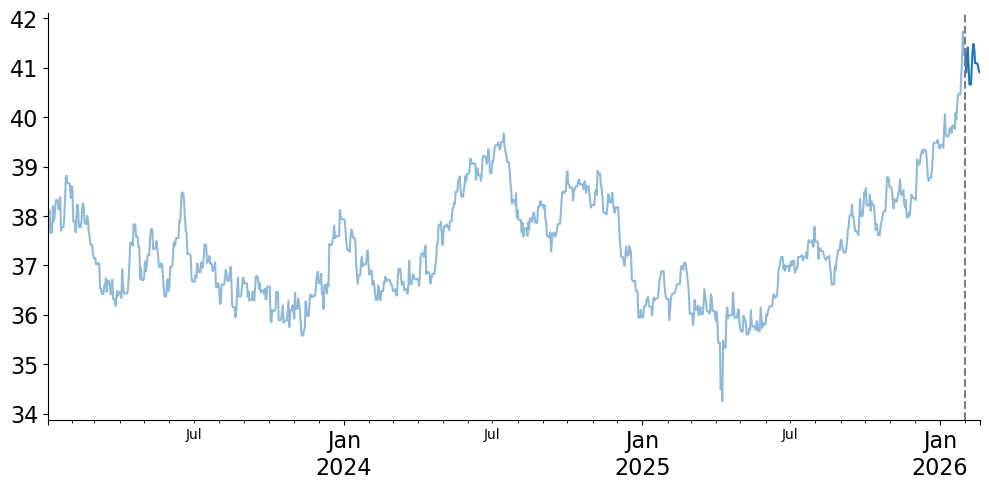

In [88]:
# Train/test split
df_train = df.query('ds < @loc_TRAIN')
df_test = df.query('ds >= @loc_TRAIN')

print(f'Test set size: {len(df_test)}')
display(df_test)

@apply_chart_template(filename='audphp.png')
def plot_aud():
    df_in = df.copy()
    df_in.set_index('ds', inplace=True)

    fig, ax = plt.subplots(figsize=(10,5))
    df_in.loc[:loc_TRAIN].plot(ax=ax,
                                label='Train',
                                color='tab:blue',
                                alpha = 0.5,
                                legend=False)
    df_in.loc[loc_TRAIN:].plot(ax=ax,
                                label='Test',
                                color='tab:blue',
                                legend=False)
    ax.axvline(loc_TRAIN, color='tab:gray', 
               linestyle='--', 
               label='Train/Test Split')
plot_aud()

### Naive model and its residuals with the train set

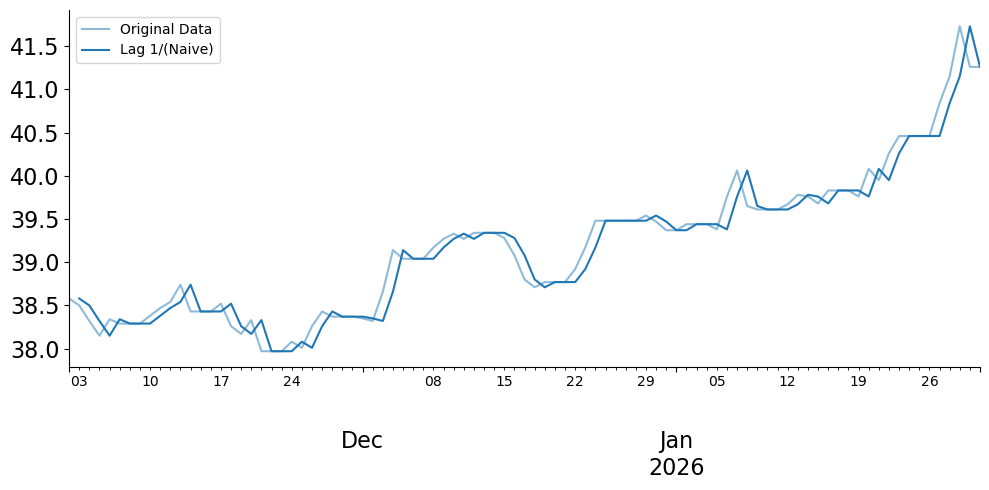

In [105]:
@apply_chart_template(filename='audphp_naive.png')
def plot_audnaive():
    fig, ax = plt.subplots(figsize=(10, 5))
    train_window = df_train['ds'].max() - pd.Timedelta(days=90)
    df_in = df_train.query('ds >= @train_window').copy()
    df_in.set_index('ds', inplace=True)
    df_in.plot(alpha = 0.5,
            color='tab:blue',
            label='Original Data',
            ax = ax)
    df_in.shift(1).plot(
            label='Lag 1',
            alpha=1.0,
            color='tab:blue',
            ax = ax)
    #set legend
    ax.legend(['Original Data', 'Lag 1/(Naive)'])

plot_audnaive()

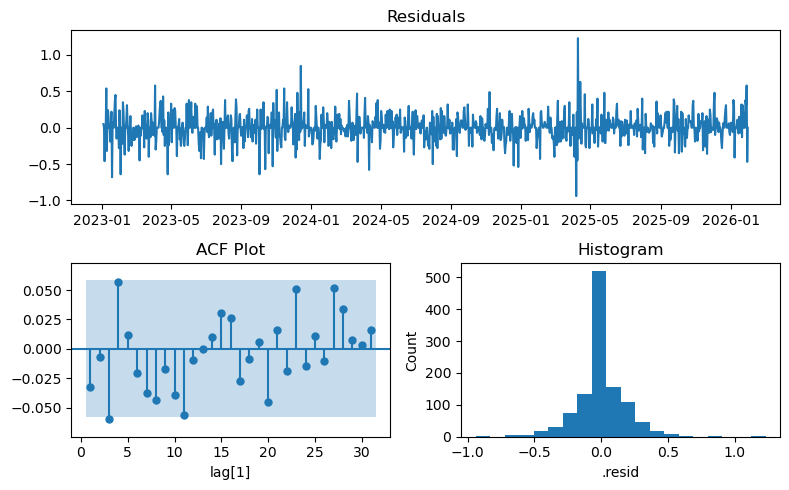

In [84]:
df_resid = df_train.copy()
df_resid['y'] = df_train['y'].diff().values
df_resid.dropna(inplace=True)

fig = plt.figure(figsize=(8, 5))

ax1 = fig.add_subplot(2, 2, (1, 2))
ax1.plot(df_resid['ds'], df_resid["y"])
ax1.set_title("Residuals")

ax2 = fig.add_subplot(2, 2, 3)
plot_acf(df_resid["y"].dropna(), ax=ax2, zero=False,
  bartlett_confint=False, auto_ylims=True)
ax2.set_title("ACF Plot")
ax2.set_xlabel('lag[1]')

ax3 = fig.add_subplot(2, 2, 4)
ax3.hist(df_resid["y"], bins=20)
ax3.set_title("Histogram")
ax3.set_xlabel(".resid")
ax3.set_ylabel("Count")

plt.tight_layout()
plt.show()



### Portmanteau tests for autocorrelation

In addition to visually inspecting the ACF, we perform formal hypothesis tests on the residuals to check for autocorrelation.

The two most common tests are the **Box-Pierce test** and the **Ljung-Box test**. See [FPP3](https://otexts.com/fpp3/diagnostics.html) for more details.

For these tests, the hypotheses are:

- $H_0$: The data are independently distributed.

- $H_1$: The data are not independently distributed; they exhibit serial correlation.

<b>RECALL:</b> If $p < \alpha$, then we reject the null hypothesis.

In [109]:
import scipy.stats as stats

resid_test = acorr_ljungbox(df_resid["y"].dropna(), boxpierce=True)
display(resid_test)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,1.189621,0.275406,1.186451,0.276047
2,1.238515,0.538344,1.235171,0.539245
3,5.286753,0.151964,5.265434,0.153361
4,8.906422,0.063482,8.865815,0.064542
5,9.066997,0.106422,9.025392,0.108056
6,9.553928,0.144738,9.508863,0.146917
7,11.153928,0.132044,11.096075,0.134483
8,13.286891,0.102352,13.210094,0.104822
9,13.622261,0.136411,13.542189,0.139568
10,15.400511,0.118128,15.301488,0.121451


In [110]:
#include test for normality
normality_test = stats.shapiro(df_resid["y"].dropna())
display(normality_test)

ShapiroResult(statistic=0.9226562976837158, pvalue=1.4330142703935485e-23)

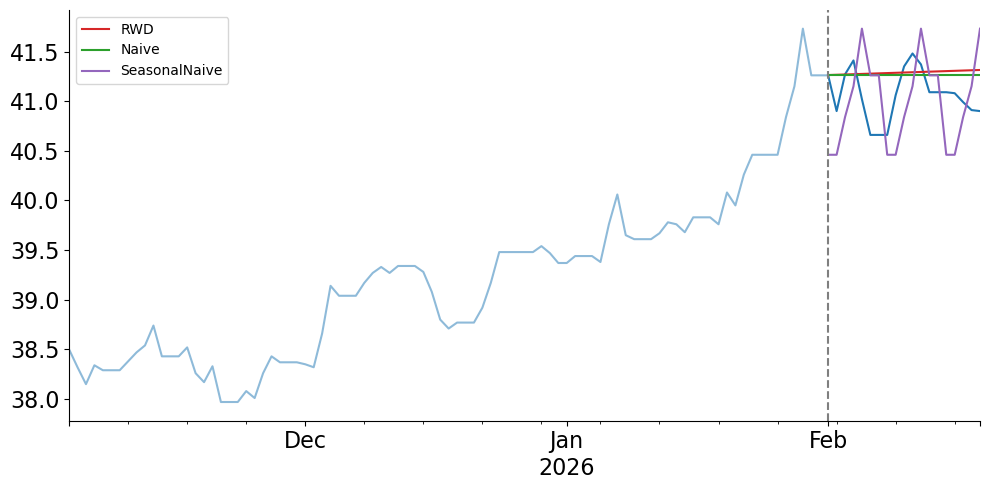

In [18]:
sf = StatsForecast(
    models=[Naive(), 
            RandomWalkWithDrift(), 
            SeasonalNaive(season_length=7)], # 4 baseline methods
    freq="D"
)

df_f = sf.forecast(h=len(df_test),
                   df=df_train,)
df_f = pd.merge(df_test, df_f, on=['ds','unique_id']) # append ground truth "y"
df_f.tail()


@apply_chart_template(filename='audphp2.png')
def plot_aud():
    df_in = df.copy()
    df_in.set_index('ds', inplace=True)

    fig, ax = plt.subplots(figsize=(10,5))

    train_window = loc_TRAIN - pd.Timedelta(days=90)
    #change labels to Train and Test
    df_in.loc[train_window:loc_TRAIN].plot(ax=ax,
                                label='Train',
                                color='tab:blue',
                                alpha= 0.5,
                                legend=False)
    df_in.loc[loc_TRAIN:].plot(ax=ax,
                                label='Test',
                                color='tab:blue',
                                legend=False)
    df_f.plot(ax=ax, 
              x='ds', 
              y=['RWD', 'Naive', 'SeasonalNaive'], 
              color=['tab:red', 'tab:green', 'tab:purple'])

    ax.axvline(loc_TRAIN, color='tab:gray', 
               linestyle='--', 
               label='Train/Test Split')
    
plot_aud()

In [117]:
from functools import partial
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape as _mape, mase, bias

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

#mean directional accuracy (MDA)
def mda(df, models, id_col = "unique_id", target_col = "y"):
    df_mda = df.copy()
    for model in models:
        pred_col = model if model in df.columns else f'{model}_pred'
        df_mda[pred_col] = np.sign(df_mda[pred_col].diff()) == np.sign(df_mda[target_col].diff())
    return df_mda.groupby(id_col).mean().reset_index().drop(columns=['ds','y'])

df_eval = evaluate(df_f,
                   metrics=[bias, mda, mae, rmse, mape, partial(mase, seasonality=7),],
                   train_df=df_train) # mase uses snaive as scaler

df_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')

metric,bias,mda,mae,rmse,mape,mase
Naive,0.194211,0.210526,0.255263,0.311406,0.623868,0.726742
RWD,0.222591,0.263158,0.271694,0.331077,0.664127,0.773521
SeasonalNaive,-0.067895,0.421053,0.455263,0.503509,1.108991,1.296148


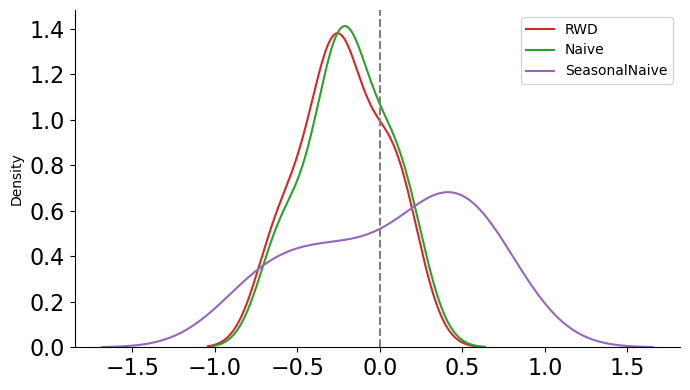

In [115]:
import seaborn as sns

df_errors = pd.DataFrame({'ds': df_f['ds']})
df_errors['e_RWD'] = df_f['y'] - df_f['RWD']
df_errors['e_Naive'] = df_f['y'] - df_f['Naive']
df_errors['e_SeasonalNaive'] = df_f['y'] - df_f['SeasonalNaive']

@apply_chart_template(filename='audphp_errors.png')
def plot_error_distributions():
    fig, ax  = plt.subplots(figsize=(7,4))
    for col, color in zip(['e_RWD', 'e_Naive', 'e_SeasonalNaive'], ['tab:red','tab:green','tab:purple']):
        sns.kdeplot(df_errors[col], ax =ax, color=color)
    
    ax.axvline(0, color='tab:gray', linestyle='--')
    ax.set_xlabel('Forecast Error')
    ax.legend(['RWD', 'Naive', 'SeasonalNaive'])

plot_error_distributions()



### Random walk with drift simulation

In [56]:
np.random.seed(42)

# 1. Estimate GBM parameters from training data
def estimate_gbm_parameters(df_train):
    """
    Estimate drift (μ) and volatility (σ) from historical data using log returns.
    
    Parameters:
    -----------
    df_train : pd.DataFrame
        Training data with 'y' column containing prices
    
    Returns:
    --------
    dict : Dictionary containing drift and volatility parameters
    """
    prices = df_train['y'].values
    log_returns = np.diff(np.log(prices))
    
    # Annualized parameters (252 trading days)
    mu = np.mean(log_returns)  # drift per day
    sigma = np.std(log_returns)  # volatility per day
    
    return {
        'mu': mu,
        'sigma': sigma,
        'S0': prices[-1],  # Starting price
        'log_returns': log_returns
    }

# 2. Generate Monte Carlo paths using GBM
def monte_carlo_gbm(S0, mu, sigma, T, n_simulations=1000, random_seed=42):
    """
    Generate price paths using Geometric Brownian Motion.
    
    dS = μ*S*dt + σ*S*dW
    S(t) = S0 * exp((μ - σ²/2)*t + σ*W(t))
    
    Parameters:
    -----------
    S0 : float
        Initial price
    mu : float
        Drift (daily)
    sigma : float
        Volatility (daily)
    T : int
        Number of time steps (days)
    n_simulations : int
        Number of simulation paths
    
    Returns:
    --------
    np.ndarray : Array of shape (n_simulations, T) with simulated paths
    """
    np.random.seed(random_seed)
    dt = 1  # daily time step
    
    # Generate random walks
    Z = np.random.standard_normal((n_simulations, T))
    
    # Calculate cumulative returns
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    
    log_returns = drift + diffusion
    cum_log_returns = np.cumsum(log_returns, axis=1)
    
    # Calculate price paths
    paths = S0 * np.exp(cum_log_returns)
    
    return paths

# 3. Estimate parameters
params = estimate_gbm_parameters(df_train)
# 4. Run Monte Carlo simulation
n_simulations = 1000
horizon = len(df_test)
mc_paths = monte_carlo_gbm(
    S0=params['S0'],
    mu=params['mu'],
    sigma=params['sigma'],
    T=horizon,
    n_simulations=n_simulations
)

df_mc_paths = pd.DataFrame(mc_paths).T
df_mc_paths.columns = [f"Path_{i}" for i in range(n_simulations)]
df_mc_paths['ds'] = df_test['ds'].values


# 5. Calculate statistics
df_mc_paths_stat = df_mc_paths.drop(columns=['ds']).T.describe().T
df_mc_paths_stat['ds']= df_mc_paths['ds']
df_mc_paths_stat


,count,mean,std,min,25%,50%,75%,max,ds
0,1000.0,41.263681,0.210080,40.551651,41.122754,41.258535,41.399843,42.029456,2026-02-01
1,1000.0,41.278337,0.287013,40.449924,41.075631,41.279528,41.462330,42.178255,2026-02-02
2,1000.0,41.276532,0.345557,40.110509,41.039199,41.269643,41.507019,42.613975,2026-02-03
3,1000.0,41.278179,0.395913,39.953839,41.001984,41.258233,41.538411,42.732566,2026-02-04
4,1000.0,41.290822,0.441213,39.862581,40.977917,41.282939,41.579058,42.861775,2026-02-05
5,1000.0,41.290189,0.477057,39.917234,40.963794,41.294481,41.615240,42.939896,2026-02-06
6,1000.0,41.300552,0.507250,39.823859,40.940987,41.281374,41.638637,43.143558,2026-02-07
7,1000.0,41.312849,0.537542,39.765324,40.940924,41.320055,41.683064,43.428319,2026-02-08
8,1000.0,41.318355,0.572446,39.909509,40.928359,41.301084,41.709108,43.311650,2026-02-09
9,1000.0,41.317048,0.606005,39.623624,40.892879,41.296323,41.713142,43.366710,2026-02-10


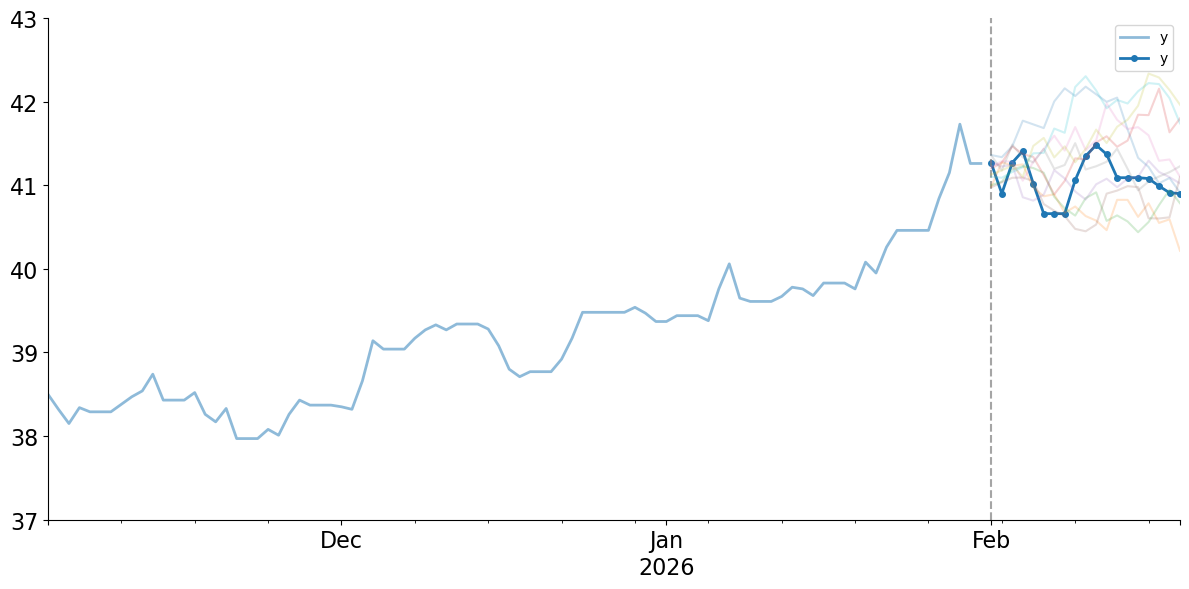

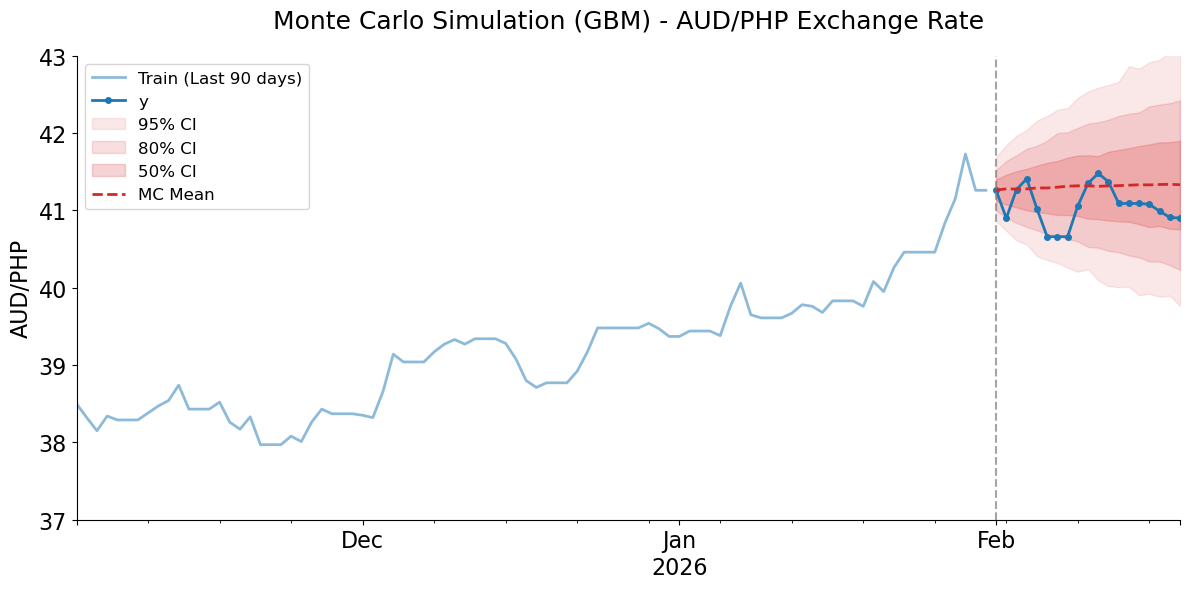

In [118]:

# Confidence intervals
percentiles = {
    '95': (np.percentile(mc_paths, 2.5, axis=0), np.percentile(mc_paths, 97.5, axis=0)),
    '80': (np.percentile(mc_paths, 10, axis=0), np.percentile(mc_paths, 90, axis=0)),
    '50': (np.percentile(mc_paths, 25, axis=0), np.percentile(mc_paths, 75, axis=0)),
}



@apply_chart_template(filename='audphp_montecarlo_path.png')
def plot_montecarlo_paths(sample_N_paths=10):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot training data (last 90 days)
    train_window = loc_TRAIN - pd.Timedelta(days=90)
    df_train_window = df_train[df_train['ds'] >= train_window].copy()
    df_train_window.set_index('ds', inplace=True)
    df_train_window.plot(color='tab:blue', 
                         alpha=0.5, 
                         label='Train (Last 90 days)', linewidth=2, ax=ax)


    # Plot actual test data
    df_test_plot = df_test.copy()
    df_test_plot.set_index('ds', inplace=True)
    df_test_plot.plot(color='tab:blue', label='Actual', linewidth=2, marker='o', markersize=4, ax=ax)

    # Split line
    ax.axvline(loc_TRAIN, color='tab:gray', linestyle='--', alpha=0.7)
    

    df_mc_paths2 = df_mc_paths.copy()
    df_mc_paths2.set_index('ds', inplace=True)

    df_mc_paths2.iloc[:, :sample_N_paths].plot(alpha=0.2, ax=ax, legend=False)

    ax.set_ylim([37,43])


# 7. Visualization
@apply_chart_template(filename='audphp_montecarlo.png')
def plot_montecarlo():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot training data (last 90 days)
    train_window = loc_TRAIN - pd.Timedelta(days=90)
    df_train_window = df_train[df_train['ds'] >= train_window].copy()

    df_train_window.set_index('ds', inplace=True)
    df_train_window.plot(y='y', 
            color='tab:blue', alpha=0.5, label='Train (Last 90 days)', linewidth=2, ax=ax)
    
    # Plot actual test data
    df_test_plot = df_test.copy()
    df_test_plot.set_index('ds', inplace=True)
    df_test_plot.plot(color='tab:blue', label='Actual', linewidth=2, marker='o', markersize=4, ax=ax)
       
    # Plot confidence intervals
    ax.fill_between(df_test['ds'].values, percentiles['95'][0], percentiles['95'][1],
                     color='tab:red', alpha=0.1, label='95% CI')
    ax.fill_between(df_test['ds'].values, percentiles['80'][0], percentiles['80'][1],
                     color='tab:red', alpha=0.15, label='80% CI')
    ax.fill_between(df_test['ds'].values, percentiles['50'][0], percentiles['50'][1],
                     color='tab:red', alpha=0.2, label='50% CI')
    
    # Plot mean forecast
    ax.plot(df_test['ds'], df_mc_paths_stat['mean'], 
            color='tab:red', label='MC Mean', linewidth=2, linestyle='--')
    
    # Split line
    ax.axvline(loc_TRAIN, color='tab:gray', linestyle='--', alpha=0.7)
    
    ax.legend(loc='best', fontsize=12)
    ax.set_ylabel('AUD/PHP', fontsize=16)
    ax.set_title('Monte Carlo Simulation (GBM) - AUD/PHP Exchange Rate', fontsize=18, pad=20)
    ax.set_ylim([37,43])
    
plot_montecarlo_paths()
plot_montecarlo()


### Australian Beer Production

### Summary: